In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
sns.set_theme(style="darkgrid")
plt.style.use('ggplot')
warnings.filterwarnings('ignore')

SEED = 0

# Анализ данных

## Загрузка данных

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Hackatons/AgroCode/train.csv')
test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Hackatons/AgroCode/test.csv')

print(train.shape, test.shape)

(2838, 370) (939, 369)


## Распределение меток классов

In [ ]:
train.Culture.value_counts()

4     1301
3      338
7      246
9      186
5      132
14      87
8       85
12      78
10      60
16      58
2       49
11      45
1       36
13      33
21      25
17      21
6       14
22       8
15       7
20       7
23       6
24       6
28       2
18       2
25       2
19       2
26       1
27       1
Name: Culture, dtype: int64

In [ ]:
train = train.append(train[train.Culture == 26].copy(), ignore_index=True)
train = train.append(train[train.Culture == 27].copy(), ignore_index=True)

In [ ]:
train.Culture.value_counts()

4     1301
3      338
7      246
9      186
5      132
14      87
8       85
12      78
10      60
16      58
2       49
11      45
1       36
13      33
21      25
17      21
6       14
22       8
15       7
20       7
23       6
24       6
27       2
18       2
26       2
25       2
19       2
28       2
Name: Culture, dtype: int64

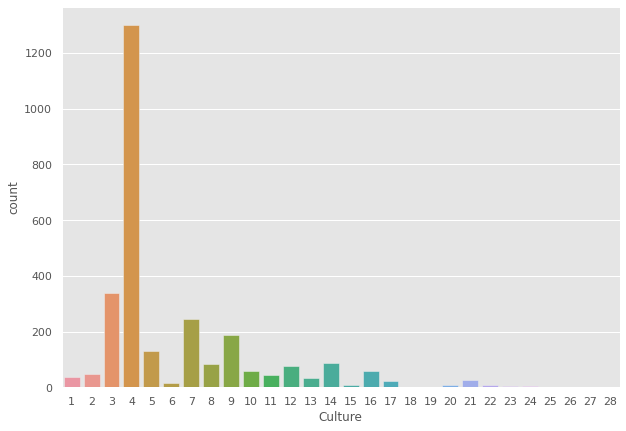

In [ ]:
plt.figure(figsize=(10, 7))
sns.countplot(train.Culture)
None

## Размерность признаков

In [ ]:
train.describe()

,Year,Field ID,Field Area,Day 1,Day 2,Day 3,Day 4,Day 5,Day 6,Day 7,Day 8,Day 9,Day 10,Day 11,Day 12,Day 13,Day 14,Day 15,Day 16,Day 17,Day 18,Day 19,Day 20,Day 21,Day 22,Day 23,Day 24,Day 25,Day 26,Day 27,Day 28,Day 29,Day 30,Day 31,Day 32,Day 33,Day 34,Day 35,Day 36,Day 37,...,Day 328,Day 329,Day 330,Day 331,Day 332,Day 333,Day 334,Day 335,Day 336,Day 337,Day 338,Day 339,Day 340,Day 341,Day 342,Day 343,Day 344,Day 345,Day 346,Day 347,Day 348,Day 349,Day 350,Day 351,Day 352,Day 353,Day 354,Day 355,Day 356,Day 357,Day 358,Day 359,Day 360,Day 361,Day 362,Day 363,Day 364,Day 365,Day 366,Culture
count,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,2840.000000,...,2648.000000,2649.000000,2532.000000,2532.000000,2532.000000,2532.000000,2530.000000,2530.000000,2530.000000,2530.000000,2530.000000,2530.000000,2530.000000,2486.000000,2486.000000,2486.000000,2385.000000,2391.000000,2363.000000,2363.000000,2363.000000,2363.000000,2363.000000,2363.000000,2363.000000,2363.000000,2363.000000,2363.000000,2363.000000,2363.000000,2363.000000,2363.000000,2363.000000,2363.000000,2363.000000,2363.000000,2363.000000,2363.000000,447.000000,2840.000000
mean,2017.259155,845.994366,106.671415,0.207384,0.205846,0.204321,0.202832,0.201692,0.200619,0.199539,0.197992,0.195004,0.191597,0.189353,0.187268,0.185245,0.183268,0.180569,0.177403,0.174325,0.171374,0.168581,0.165819,0.164566,0.163685,0.162638,0.162053,0.161264,0.160855,0.161100,0.161468,0.162727,0.164007,0.165251,0.166673,0.167769,0.168665,0.169471,0.170153,0.170803,...,0.267396,0.260441,0.258258,0.254029,0.250574,0.247684,0.244971,0.242211,0.239615,0.238935,0.238909,0.238892,0.238867,0.239268,0.239751,0.239833,0.237117,0.236555,0.235977,0.234153,0.231679,0.228948,0.225003,0.221233,0.217712,0.214125,0.210584,0.207192,0.203817,0.200899,0.198460,0.196298,0.191437,0.186595,0.181753,0.177603,0.173354,0.168824,0.088671,6.214437
std,1.256370,605.688749,73.025004,0.212476,0.211943,0.211684,0.211757,0.211909,0.212366,0.213098,0.213672,0.212978,0.211987,0.210183,0.208633,0.207502,0.206897,0.206042,0.205260,0.205033,0.205355,0.205765,0.206630,0.206443,0.206372,0.206467,0.206688,0.206931,0.207397,0.207841,0.208615,0.209152,0.210171,0.211063,0.212192,0.213406,0.214742,0.216390,0.218160,0.220273,...,0.162878,0.163407,0.166698,0.167756,0.168669,0.169346,0.170649,0.171954,0.173774,0.174111,0.174320,0.175171,0.176642,0.180111,0.182020,0.184045,0.186952,0.188901,0.191900,0.193216,0.193979,0.194537,0.194542,0.194679,0.194821,0.194982,0.195365,0.195811,0.196249,0.196224,0.195762,0.195177,0.192617,0.190451,0.188423,0.186753,0.185882,0.185577,0.126895,4.192380
min,2015.000000,1.000000,5.990000,-0.141800,-0.133400,-0.126600,-0.124800,-0.122200,-0.121200,-0.125400,-0.129700,-0.134000,-0.131700,-0.126600,-0.121600,-0.117400,-0.113300,-0.109100,-0.105000,-0.100900,-0.096700,-0.092600,-0.092000,-0.084300,-0.080100,-0.076000,-0.086600,-0.099000,-0.107600,-0.111000,-0.109500,-0.104800,-0.097600,-0.088500,-0.078100,-0.067100,-0.062900,-0.062300,-0.060800,-0.063100,...,-0.059000,-0.051700,-0.052400,-0.053000,-0.053700,-0.054400,-0.055100,-0.055700,-0.077200,-0.100000,-0.098800,-0.097600,-0.096400,-0.095200,-0.094000,-0.102000,-0.099100,-0.097000,-0.101800,-0.106600,-0.111400,-0.116200,-0.121000,-0.125800,-0.130600,-0.135400,-0.152200,-0.170000,-0.167000,-0.164000,-0.161000,-0.158000,-0.155000,-0.152000,-0.157700,-0.167000,-0.158600,-0.150200,-0.137000,1.000000
25%,2016.000000,255.750000,63.380000,0.010725,0.008850,0.007000,0.005275,0.003100,0.001000,-0.000225,-0.001825,-0.004600,-0.006300,-0.003925,-0.003525,-0.004

## Очистка

In [ ]:
train.head(5)

,Year,Field ID,Field Area,Day 1,Day 2,Day 3,Day 4,Day 5,Day 6,Day 7,Day 8,Day 9,Day 10,Day 11,Day 12,Day 13,Day 14,Day 15,Day 16,Day 17,Day 18,Day 19,Day 20,Day 21,Day 22,Day 23,Day 24,Day 25,Day 26,Day 27,Day 28,Day 29,Day 30,Day 31,Day 32,Day 33,Day 34,Day 35,Day 36,Day 37,...,Day 328,Day 329,Day 330,Day 331,Day 332,Day 333,Day 334,Day 335,Day 336,Day 337,Day 338,Day 339,Day 340,Day 341,Day 342,Day 343,Day 344,Day 345,Day 346,Day 347,Day 348,Day 349,Day 350,Day 351,Day 352,Day 353,Day 354,Day 355,Day 356,Day 357,Day 358,Day 359,Day 360,Day 361,Day 362,Day 363,Day 364,Day 365,Day 366,Culture
0,2018,517,48.64,0.5369,0.5371,0.5375,0.5379,0.5384,0.5390,0.5397,0.5405,0.5414,0.5425,0.5437,0.5450,0.5466,0.5487,0.5511,0.5539,0.5571,0.5605,0.5641,0.5679,0.5718,0.5759,0.5800,0.5842,0.5883,0.5924,0.5964,0.6003,0.6040,0.6074,0.6106,0.6135,0.6161,0.6182,0.6200,0.6214,0.6227,...,0.3700,0.3739,0.3786,0.3838,0.3896,0.3959,0.4024,0.4092,0.4162,0.4232,0.4301,0.4369,0.4435,0.4497,0.4555,0.4608,0.4655,0.4694,0.4726,0.4748,0.4760,0.4720,0.4680,0.4641,0.4601,0.4561,0.4521,0.4481,0.4442,0.4402,0.4362,0.4322,0.4283,0.4243,0.4203,0.4163,0.4123,0.4084,NaN,4
1,2019,1395,80.41,0.1159,0.1096,0.1034,0.0971,0.0909,0.0846,0.0783,0.0721,0.0658,0.0596,0.0533,0.0471,0.0408,0.0345,0.0283,0.0220,0.0158,0.0095,0.0033,-0.0030,-0.0040,-0.0043,-0.0044,-0.0046,-0.0050,-0.0054,-0.0058,-0.0062,-0.0066,-0.0070,-0.0074,-0.0078,-0.0082,-0.0086,-0.0090,-0.0094,-0.0098,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17
2,2017,44,43.64,-0.0204,-0.0207,-0.0210,-0.0212,-0.0215,-0.0218,-0.0220,-0.0222,-0.0224,-0.0226,-0.0228,-0.0230,-0.0232,-0.0234,-0.0235,-0.0236,-0.0238,-0.0239,-0.0240,-0.0241,-0.0242,-0.0243,-0.0244,-0.0245,-0.0246,-0.0247,-0.0248,-0.0249,-0.0250,-0.0251,-0.0252,-0.0253,-0.0254,-0.0255,-0.0256,-0.0257,-0.0258,...,0.1753,0.1306,0.0858,0.0410,0.0402,0.0393,0.0385,0.0376,0.0368,0.0360,0.0351,0.0343,0.0334,0.0326,0.0318,0.0309,0.0301,0.0292,0.0284,0.0276,0.0267,0.0259,0.0250,0.0242,0.0234,0.0225,0.0217,0.0208,0.0200,0.0516,0.0833,0.1149,0.1466,0.1782,0.2099,0.2415,0.2732,0.3048,NaN,2
3,2018,1591,79.34,0.4827,0.4576,0.4324,0.4073,0.3821,0.3570,0.3318,0.3067,0.2815,0.2637,0.2509,0.2356,0.2203,0.2051,0.1898,0.1745,0.1592,0.1439,0.1286,0.1133,0.0980,0.0827,0.0674,0.0522,0.0369,0.0216,0.0063,-0.0090,0.0427,0.0943,0.1460,0.1976,0.2493,0.3009,0.3526,0.4042,0.4559,...,0.2565,0.2565,0.2566,0.2566,0.2567,0.2567,0.2568,0.2568,0.2569,0.2570,0.2570,0.2571,0.2572,0.2573,0.2574,0.2575,0.2576,0.2577,0.2579,0.2580,0.2582,0.2585,0.2590,0.2595,0.2602,0.2609,0.2617,0.2626,0.2636,0.2646,0.2657,0.2668,0.2680,0.2692,0.2705,0.2717,0.2730,0.2743,NaN,4
4,2017,681,144.76,-0.0202,-0.0191,-0.0181,-0.0170,-0.0160,-0.0150,-0.0140,-0.0131,-0.0123,-0.0115,-0.0109,-0.0103,-0.0099,-0.0097,-0.0096,-0.0097,-0.0100,-0.0104,-0.0108,-0.0113,-0.0118,-0.0122,-0.0127,-0.0131,-0.0136,-0.0140,-0.0144,-0.0147,-0.0150,-0.0152,-0.0154,-0.0155,-0.0156,-0.0156,-0.0156,-0.0156,-0.0156,...,0.1758,0.1677,0.1597,0.1516,0.1435,0.1355,0.1274,0.1193,0.1113,0.1032,0.0951,0.0870,0.0790,0.0709,0.0628,0.0548,0.0467,0.0386,0.0306,0.0225,0.0144,0.0063,-0.0017,-0.0098,-0.0179,-0.0259,-0.0340,-0.0378,-0.0364,-0.0351,-0.0354,-0.0358,-0.0361,-0.0365,-0.0369,-0.0372,-0.0376,-0.0379,NaN,4


In [ ]:
train.dtypes.value_counts()

float64    367
int64        3
dtype: int64

In [ ]:
X_train = train.drop(['Culture', 'Day 366'], axis=1)
y_train = train['Culture']

X_test = test.drop(['Day 366'], axis=1)

In [ ]:
print(X_train.shape, X_test.shape, y_train.shape)

(2838, 368) (939, 368) (2838,)


In [ ]:
num_names = X_train.columns[:3]
days_names = X_train.columns[3:]
names = X_train.columns

In [ ]:
X_train.head(4)

,Year,Field ID,Field Area,Day 1,Day 2,Day 3,Day 4,Day 5,Day 6,Day 7,Day 8,Day 9,Day 10,Day 11,Day 12,Day 13,Day 14,Day 15,Day 16,Day 17,Day 18,Day 19,Day 20,Day 21,Day 22,Day 23,Day 24,Day 25,Day 26,Day 27,Day 28,Day 29,Day 30,Day 31,Day 32,Day 33,Day 34,Day 35,Day 36,Day 37,...,Day 326,Day 327,Day 328,Day 329,Day 330,Day 331,Day 332,Day 333,Day 334,Day 335,Day 336,Day 337,Day 338,Day 339,Day 340,Day 341,Day 342,Day 343,Day 344,Day 345,Day 346,Day 347,Day 348,Day 349,Day 350,Day 351,Day 352,Day 353,Day 354,Day 355,Day 356,Day 357,Day 358,Day 359,Day 360,Day 361,Day 362,Day 363,Day 364,Day 365
0,2018,517,48.64,0.5369,0.5371,0.5375,0.5379,0.5384,0.5390,0.5397,0.5405,0.5414,0.5425,0.5437,0.5450,0.5466,0.5487,0.5511,0.5539,0.5571,0.5605,0.5641,0.5679,0.5718,0.5759,0.5800,0.5842,0.5883,0.5924,0.5964,0.6003,0.6040,0.6074,0.6106,0.6135,0.6161,0.6182,0.6200,0.6214,0.6227,...,0.3631,0.3665,0.3700,0.3739,0.3786,0.3838,0.3896,0.3959,0.4024,0.4092,0.4162,0.4232,0.4301,0.4369,0.4435,0.4497,0.4555,0.4608,0.4655,0.4694,0.4726,0.4748,0.4760,0.4720,0.468,0.4641,0.4601,0.4561,0.4521,0.4481,0.4442,0.4402,0.4362,0.4322,0.4283,0.4243,0.4203,0.4163,0.4123,0.4084
1,2019,1395,80.41,0.1159,0.1096,0.1034,0.0971,0.0909,0.0846,0.0783,0.0721,0.0658,0.0596,0.0533,0.0471,0.0408,0.0345,0.0283,0.0220,0.0158,0.0095,0.0033,-0.0030,-0.0040,-0.0043,-0.0044,-0.0046,-0.0050,-0.0054,-0.0058,-0.0062,-0.0066,-0.0070,-0.0074,-0.0078,-0.0082,-0.0086,-0.0090,-0.0094,-0.0098,...,0.2635,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2017,44,43.64,-0.0204,-0.0207,-0.0210,-0.0212,-0.0215,-0.0218,-0.0220,-0.0222,-0.0224,-0.0226,-0.0228,-0.0230,-0.0232,-0.0234,-0.0235,-0.0236,-0.0238,-0.0239,-0.0240,-0.0241,-0.0242,-0.0243,-0.0244,-0.0245,-0.0246,-0.0247,-0.0248,-0.0249,-0.0250,-0.0251,-0.0252,-0.0253,-0.0254,-0.0255,-0.0256,-0.0257,-0.0258,...,0.2649,0.2201,0.1753,0.1306,0.0858,0.0410,0.0402,0.0393,0.0385,0.0376,0.0368,0.0360,0.0351,0.0343,0.0334,0.0326,0.0318,0.0309,0.0301,0.0292,0.0284,0.0276,0.0267,0.0259,0.025,0.0242,0.0234,0.0225,0.0217,0.0208,0.0200,0.0516,0.0833,0.1149,0.1466,0.1782,0.2099,0.2415,0.2732,0.3048
3,2018,1591,79.34,0.4827,0.4576,0.4324,0.4073,0.3821,0.3570,0.3318,0.3067,0.2815,0.2637,0.2509,0.2356,0.2203,0.2051,0.1898,0.1745,0.1592,0.1439,0.1286,0.1133,0.0980,0.0827,0.0674,0.0522,0.0369,0.0216,0.0063,-0.0090,0.0427,0.0943,0.1460,0.1976,0.2493,0.3009,0.3526,0.4042,0.4559,...,0.2567,0.2566,0.2565,0.2565,0.2566,0.2566,0.2567,0.2567,0.2568,0.2568,0.2569,0.2570,0.2570,0.2571,0.2572,0.2573,0.2574,0.2575,0.2576,0.2577,0.2579,0.2580,0.2582,0.2585,0.259,0.2595,0.2602,0.2609,0.2617,0.2626,0.2636,0.2646,0.2657,0.2668,0.2680,0.2692,0.2705,0.2717,0.2730,0.2743


## NaN

In [ ]:
X_train.isna().sum(axis=0)

Year            0
Field ID        0
Field Area      0
Day 1           0
Day 2           0
             ... 
Day 361       476
Day 362       476
Day 363       476
Day 364       476
Day 365       476
Length: 368, dtype: int64

In [ ]:
%%time
imputer = KNNImputer(n_neighbors=9, weights="distance")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=names)
X_test = pd.DataFrame(imputer.transform(X_test), columns=names)

CPU times: user 6.06 s, sys: 270 ms, total: 6.33 s
Wall time: 5.83 s


In [ ]:
X_train.isna().values.any()

False

## Переводим дни в недели

In [ ]:
X_train.head()

,Year,Field ID,Field Area,Day 1,Day 2,Day 3,Day 4,Day 5,Day 6,Day 7,Day 8,Day 9,Day 10,Day 11,Day 12,Day 13,Day 14,Day 15,Day 16,Day 17,Day 18,Day 19,Day 20,Day 21,Day 22,Day 23,Day 24,Day 25,Day 26,Day 27,Day 28,Day 29,Day 30,Day 31,Day 32,Day 33,Day 34,Day 35,Day 36,Day 37,...,Day 326,Day 327,Day 328,Day 329,Day 330,Day 331,Day 332,Day 333,Day 334,Day 335,Day 336,Day 337,Day 338,Day 339,Day 340,Day 341,Day 342,Day 343,Day 344,Day 345,Day 346,Day 347,Day 348,Day 349,Day 350,Day 351,Day 352,Day 353,Day 354,Day 355,Day 356,Day 357,Day 358,Day 359,Day 360,Day 361,Day 362,Day 363,Day 364,Day 365
0,2018.0,517.0,48.64,0.5369,0.5371,0.5375,0.5379,0.5384,0.5390,0.5397,0.5405,0.5414,0.5425,0.5437,0.5450,0.5466,0.5487,0.5511,0.5539,0.5571,0.5605,0.5641,0.5679,0.5718,0.5759,0.5800,0.5842,0.5883,0.5924,0.5964,0.6003,0.6040,0.6074,0.6106,0.6135,0.6161,0.6182,0.6200,0.6214,0.6227,...,0.3631,0.366500,0.370000,0.373900,0.378600,0.383800,0.389600,0.395900,0.402400,0.409200,0.416200,0.423200,0.430100,0.436900,0.443500,0.449700,0.455500,0.460800,0.465500,0.469400,0.472600,0.474800,0.476000,0.472000,0.468000,0.464100,0.460100,0.456100,0.452100,0.448100,0.444200,0.440200,0.436200,0.43220,0.42830,0.424300,0.420300,0.416300,0.412300,0.408400
1,2019.0,1395.0,80.41,0.1159,0.1096,0.1034,0.0971,0.0909,0.0846,0.0783,0.0721,0.0658,0.0596,0.0533,0.0471,0.0408,0.0345,0.0283,0.0220,0.0158,0.0095,0.0033,-0.0030,-0.0040,-0.0043,-0.0044,-0.0046,-0.0050,-0.0054,-0.0058,-0.0062,-0.0066,-0.0070,-0.0074,-0.0078,-0.0082,-0.0086,-0.0090,-0.0094,-0.0098,...,0.2635,0.229006,0.221955,0.214915,0.207853,0.200825,0.193774,0.186723,0.179672,0.172646,0.165604,0.158572,0.152536,0.146499,0.140456,0.134414,0.128399,0.122395,0.116364,0.110375,0.104385,0.098438,0.092515,0.087618,0.082744,0.077906,0.073138,0.068429,0.064953,0.061502,0.058059,0.054583,0.051107,0.04763,0.04416,0.040721,0.037245,0.033769,0.030326,0.026856
2,2017.0,44.0,43.64,-0.0204,-0.0207,-0.0210,-0.0212,-0.0215,-0.0218,-0.0220,-0.0222,-0.0224,-0.0226,-0.0228,-0.0230,-0.0232,-0.0234,-0.0235,-0.0236,-0.0238,-0.0239,-0.0240,-0.0241,-0.0242,-0.0243,-0.0244,-0.0245,-0.0246,-0.0247,-0.0248,-0.0249,-0.0250,-0.0251,-0.0252,-0.0253,-0.0254,-0.0255,-0.0256,-0.0257,-0.0258,...,0.2649,0.220100,0.175300,0.130600,0.085800,0.041000,0.040200,0.039300,0.038500,0.037600,0.036800,0.036000,0.035100,0.034300,0.033400,0.032600,0.031800,0.030900,0.030100,0.029200,0.028400,0.027600,0.026700,0.025900,0.025000,0.024200,0.023400,0.022500,0.021700,0.020800,0.020000,0.051600,0.083300,0.11490,0.14660,0.178200,0.209900,0.241500,0.273200,0.304800
3,2018.0,1591.0,79.34,0.4827,0.4576,0.4324,0.4073,0.3821,0.3570,0.3318,0.3067,0.2815,0.2637,0.2509,0.2356,0.2203,0.2051,0.1898,0.1745,0.1592,0.1439,0.1286,0.1133,0.0980,0.0827,0.0674,0.0522,0.0369,0.0216,0.0063,-0.0090,0.0427,0.0943,0.1460,0.1976,0.2493,0.3009,0.3526,0.4042,0.4559,...,0.2567,0.256600,0.256500,0.256500,0.256600,0.256600,0.256700,0.256700,0.256800,0.256800,0.256900,0.257000,0.257000,0.257100,0.257200,0.257300,0.257400,0.257500,0.257600,0.257700,0.257900,0.258000,0.258200,0.258500,0.259000,0.259500,0.260200,0.260900,0.261700,0.262600,0.263600,0.264600,0.265700,0.26680,0.26800,0.269200,0.270500,0.271700,0.273000,0.274300
4,2017.0,681.0,144.76,-0.0202,-0.0191,-0.0181,-0.0170,-0.0160,-0.0150,-0.0140,-0.0131,-0.0123,-0.0115,-0.0109,-0.0103,-0.0099,-0.0097,-0.0096,-0.0097,-0.0100,-0.0104,-0.0108,-0.0113,-0.0118,-0.0122,-0.0127,-0.0131,-0.0136,-0.0140,-0.0144,-0.0147,-0.0150,-0.0152,-0.0154,-0.0155,-0.0156,-0.0156,-0.0156,-0.0156,-0.0156,...,0.1920,0.183900,0.175800,0.167700,0.159700,0.151600,0.143500,0.135500,0.127400,0.119300,0.111300,0.103200,0.095100,0.087000,0.079000,0.070900,0.062800,0.054800,0.046700,0.038600,0.030600,0.022500,0.014400,0.006300,-0.001700,-0.009800,-0.017900,-0.025900,-0.034000,-0.037800,-0.036400,-0.035100,-0.035400,-0.03580,-0.03610,-0.036500,-0.036900,-0.037200,-0.037600,-0.037900


In [ ]:
train_num = X_train.iloc[:, :3]
test_num = X_test.iloc[:, :3]

train_days = X_train.iloc[:, 3:]
test_days = X_test.iloc[:, 3:]
train_days.head(5)

,Day 1,Day 2,Day 3,Day 4,Day 5,Day 6,Day 7,Day 8,Day 9,Day 10,Day 11,Day 12,Day 13,Day 14,Day 15,Day 16,Day 17,Day 18,Day 19,Day 20,Day 21,Day 22,Day 23,Day 24,Day 25,Day 26,Day 27,Day 28,Day 29,Day 30,Day 31,Day 32,Day 33,Day 34,Day 35,Day 36,Day 37,Day 38,Day 39,Day 40,...,Day 326,Day 327,Day 328,Day 329,Day 330,Day 331,Day 332,Day 333,Day 334,Day 335,Day 336,Day 337,Day 338,Day 339,Day 340,Day 341,Day 342,Day 343,Day 344,Day 345,Day 346,Day 347,Day 348,Day 349,Day 350,Day 351,Day 352,Day 353,Day 354,Day 355,Day 356,Day 357,Day 358,Day 359,Day 360,Day 361,Day 362,Day 363,Day 364,Day 365
0,0.5369,0.5371,0.5375,0.5379,0.5384,0.5390,0.5397,0.5405,0.5414,0.5425,0.5437,0.5450,0.5466,0.5487,0.5511,0.5539,0.5571,0.5605,0.5641,0.5679,0.5718,0.5759,0.5800,0.5842,0.5883,0.5924,0.5964,0.6003,0.6040,0.6074,0.6106,0.6135,0.6161,0.6182,0.6200,0.6214,0.6227,0.6238,0.6247,0.6255,...,0.3631,0.366500,0.370000,0.373900,0.378600,0.383800,0.389600,0.395900,0.402400,0.409200,0.416200,0.423200,0.430100,0.436900,0.443500,0.449700,0.455500,0.460800,0.465500,0.469400,0.472600,0.474800,0.476000,0.472000,0.468000,0.464100,0.460100,0.456100,0.452100,0.448100,0.444200,0.440200,0.436200,0.43220,0.42830,0.424300,0.420300,0.416300,0.412300,0.408400
1,0.1159,0.1096,0.1034,0.0971,0.0909,0.0846,0.0783,0.0721,0.0658,0.0596,0.0533,0.0471,0.0408,0.0345,0.0283,0.0220,0.0158,0.0095,0.0033,-0.0030,-0.0040,-0.0043,-0.0044,-0.0046,-0.0050,-0.0054,-0.0058,-0.0062,-0.0066,-0.0070,-0.0074,-0.0078,-0.0082,-0.0086,-0.0090,-0.0094,-0.0098,-0.0102,-0.0106,-0.0110,...,0.2635,0.229006,0.221955,0.214915,0.207853,0.200825,0.193774,0.186723,0.179672,0.172646,0.165604,0.158572,0.152536,0.146499,0.140456,0.134414,0.128399,0.122395,0.116364,0.110375,0.104385,0.098438,0.092515,0.087618,0.082744,0.077906,0.073138,0.068429,0.064953,0.061502,0.058059,0.054583,0.051107,0.04763,0.04416,0.040721,0.037245,0.033769,0.030326,0.026856
2,-0.0204,-0.0207,-0.0210,-0.0212,-0.0215,-0.0218,-0.0220,-0.0222,-0.0224,-0.0226,-0.0228,-0.0230,-0.0232,-0.0234,-0.0235,-0.0236,-0.0238,-0.0239,-0.0240,-0.0241,-0.0242,-0.0243,-0.0244,-0.0245,-0.0246,-0.0247,-0.0248,-0.0249,-0.0250,-0.0251,-0.0252,-0.0253,-0.0254,-0.0255,-0.0256,-0.0257,-0.0258,-0.0259,-0.0260,-0.0269,...,0.2649,0.220100,0.175300,0.130600,0.085800,0.041000,0.040200,0.039300,0.038500,0.037600,0.036800,0.036000,0.035100,0.034300,0.033400,0.032600,0.031800,0.030900,0.030100,0.029200,0.028400,0.027600,0.026700,0.025900,0.025000,0.024200,0.023400,0.022500,0.021700,0.020800,0.020000,0.051600,0.083300,0.11490,0.14660,0.178200,0.209900,0.241500,0.273200,0.304800
3,0.4827,0.4576,0.4324,0.4073,0.3821,0.3570,0.3318,0.3067,0.2815,0.2637,0.2509,0.2356,0.2203,0.2051,0.1898,0.1745,0.1592,0.1439,0.1286,0.1133,0.0980,0.0827,0.0674,0.0522,0.0369,0.0216,0.0063,-0.0090,0.0427,0.0943,0.1460,0.1976,0.2493,0.3009,0.3526,0.4042,0.4559,0.5075,0.5084,0.5093,...,0.2567,0.256600,0.256500,0.256500,0.256600,0.256600,0.256700,0.256700,0.256800,0.256800,0.256900,0.257000,0.257000,0.257100,0.257200,0.257300,0.257400,0.257500,0.257600,0.257700,0.257900,0.258000,0.258200,0.258500,0.259000,0.259500,0.260200,0.260900,0.261700,0.262600,0.263600,0.264600,0.265700,0.26680,0.26800,0.269200,0.270500,0.271700,0.273000,0.274300
4,-0.0202,-0.0191,-0.0181,-0.0170,-0.0160,-0.0150,-0.0140,-0.0131,-0.0123,-0.0115,-0.0109,-0.0103,-0.0099,-0.0097,-0.0096,-0.0097,-0.0100,-0.0104,-0.0108,-0.0113,-0.0118,-0.0122,-0.0127,-0.0131,-0.0136,-0.0140,-0.0144,-0.0147,-0.0150,-0.0152,-0.0154,-0.0155,-0.0156,-0.0156,-0.0156,-0.0156,-0.0156,-0.0156,-0.0155,-0.0155,...,0.1920,0.183900,0.175800,0.167700,0.159700,0.151600,0.143500,0.135500,0.127400,0.119300,0.111300,0.103200,0.095100,0.087000,0.079000,0.070900,0.062800,0.054800,0.046700,0.038600,0.030600,0.022500,0.014400,0.006300,-0.001700,-0.009800,-0.017900,-0.025900,-0.034000,-0.037800,-0.036400,-0.035100,-0.035400,-0.03580,-0.03610,-0.036500,-0.036900,-0.037200,-0.037600,-0.037900


In [ ]:
train_week = pd.DataFrame([])
test_week = pd.DataFrame([])

week_num = 1
for i in range(0, len(train_days.columns), 7):
    if i == len(train_days.columns) - 1 - 7:
        train_series = pd.Series(train_days.iloc[:, i:].sum(axis=1) / 7, 
                           name=f'Week {week_num}')
        test_series = pd.Series(test_days.iloc[:, i:].sum(axis=1) / 7, 
                           name=f'Week {week_num}')
        
        train_week = pd.concat([train_week, train_series], axis=1)
        test_week = pd.concat([test_week, test_series], axis=1)
        break
    else:
        train_series = pd.Series(train_days.iloc[:, i:i + 7].sum(axis=1) / 7, 
                           name=f'Week {week_num}')
        test_series = pd.Series(test_days.iloc[:, i:i + 7].sum(axis=1) / 7, 
                           name=f'Week {week_num}')
        
        train_week = pd.concat([train_week, train_series], axis=1)
        test_week = pd.concat([test_week, test_series], axis=1)
    week_num += 1

In [ ]:
X_train = pd.concat([train_num, train_week], axis=1)
X_test = pd.concat([test_num, test_week], axis=1)
X_train.describe()

,Year,Field ID,Field Area,Week 1,Week 2,Week 3,Week 4,Week 5,Week 6,Week 7,Week 8,Week 9,Week 10,Week 11,Week 12,Week 13,Week 14,Week 15,Week 16,Week 17,Week 18,Week 19,Week 20,Week 21,Week 22,Week 23,Week 24,Week 25,Week 26,Week 27,Week 28,Week 29,Week 30,Week 31,Week 32,Week 33,Week 34,Week 35,Week 36,Week 37,Week 38,Week 39,Week 40,Week 41,Week 42,Week 43,Week 44,Week 45,Week 46,Week 47,Week 48,Week 49,Week 50,Week 51,Week 52
count,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000
mean,2017.259338,845.647639,106.608302,0.203292,0.190086,0.171933,0.161995,0.166504,0.170640,0.172493,0.182094,0.199241,0.218957,0.240977,0.268678,0.306705,0.359065,0.419184,0.470690,0.508079,0.544497,0.581985,0.614348,0.639168,0.657205,0.656042,0.633901,0.599214,0.563462,0.533322,0.510316,0.492291,0.475834,0.453970,0.427804,0.400138,0.373310,0.348746,0.329604,0.319155,0.315523,0.314266,0.315089,0.317900,0.320669,0.325244,0.329355,0.328051,0.310824,0.276174,0.250798,0.240397,0.232080,0.210438,0.212808
std,1.255671,605.755332,72.944998,0.211407,0.209234,0.204912,0.206284,0.211595,0.222368,0.224831,0.219796,0.219162,0.223589,0.229898,0.237885,0.233919,0.226108,0.223793,0.232272,0.242973,0.245098,0.238647,0.227284,0.208833,0.187588,0.165475,0.156607,0.170319,0.184265,0.199174,0.211556,0.213536,0.208220,0.199503,0.188302,0.174838,0.159917,0.143360,0.125064,0.113664,0.107673,0.104918,0.105336,0.108985,0.114003,0.119698,0.127889,0.135176,0.141602,0.152326,0.161414,0.168655,0.179033,0.182532,0.202669
min,2015.000000,1.000000,5.990000,-0.123471,-0.124900,-0.096714,-0.091771,-0.076800,-0.066157,-0.074914,-0.086357,-0.094857,-0.084871,-0.083000,-0.087543,-0.081886,-0.084429,-0.005643,0.084500,0.160843,0.196786,0.210157,0.228100,0.229900,0.213843,0.202914,0.197443,0.197014,0.187529,0.161400,0.165671,0.155914,0.152257,0.158600,0.140286,0.138071,0.137086,0.135586,0.132157,0.133386,0.138000,0.138300,0.140229,0.143600,0.072200,0.026243,0.016914,0.006543,-0.013514,-0.026757,-0.054386,-0.096400,-0.106600,-0.143314,-0.172000
25%,2016.000000,255.250000,63.380000,0.005879,-0.001996,-0.009596,-0.014600,-0.016832,-0.019264,-0.020421,-0.017300,-0.018000,-0.019421,-0.017311,0.000646,0.095168,0.202304,0.251911,0.274629,0.291321,0.316296,0.353757,0.392082,0.443804,0.501007,0.544857,0.526746,0.448532,0.396518,0.347843,0.317404,0.297993,0.293193,0.287071,0.279268,0.266918,0.257714,0.249243,0.243943,0.243079,0.245346,0.244071,0.242546,0.242468,0.244161,0.246429,0.245421,0.237043,0.217589,0.185675,0.132415,0.106811,0.076304,0.045457,0.026654
50%,2017.000000,743.500000,87.185000,0.154300,0.136950,0.100636,0.079814,0.081836,0.060479,0.068114,0.127214,0.209750,0.240543,0.251179,0.261221,0.271314,0.284700,0.309993,0.356050,0.391229,0.442964,0.518057,0.600793,0.676986,0.701850,0.679450,0.658921,0.634057,0.580293,0.523207,0.464550,0.426557,0.403064,0.378771,0.356607,0.341364,0.323250,0.305093,0.295771,0.288650,0.286007,0.286929,0.291629,0.294536,0.295436,0.297957,0.297650,0.293071,0.276486,0.256829,0.251714,0.242445,0.237107,0.202726,0.193835
75%,2018.000000,1463.750000,124.370000,0.353150,0.330361,0.297257,0.285568,0.304975,0.329743,0.339504,0.348621,0.362975,0.395707,0.429382,0.464014,0.498807,0.554882,0.643207,0.724996,0.783021,0.821132,0.843600,0.849811,0.841739,0.828432,0.796468,0.765861,0.736082,0.727607,0.724875,0.723121,0.705768,0.678257,0.633114,0.565314,0.497089,0.447493,0.4

## Train Valid Split

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

polynom = PolynomialFeatures(degree=2)
X_train = polynom.fit_transform(X_train)
X_test = polynom.transform(X_test)
X_train.shape, X_test.shape

((2838, 1596), (939, 1596))

In [ ]:
X_tt, X_tv, y_tt, y_tv = train_test_split(X_train, y_train, test_size=0.2, random_state=SEED)

# Модели

## Logistic Regression

Pipeline(memory=None,
         steps=[('standardscaler',
                 StandardScaler(copy=True, with_mean=True, with_std=True)),
                ('logisticregression',
                 LogisticRegression(C=1, class_weight=None, dual=False,
                                    fit_intercept=True, intercept_scaling=1,
                                    l1_ratio=None, max_iter=100,
                                    multi_class='auto', n_jobs=None,
                                    penalty='l2', random_state=0,
                                    solver='lbfgs', tol=0.0001, verbose=0,
                                    warm_start=False))],
         verbose=False)\
CV score: 0.7823826628174897\
Test score: 0.5814288401020478

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(k_neighbors=1, random_state=SEED)

X_train, y_train = smote.fit_sample(X_train, y_train)
X_train.shape

(36428, 368)

In [ ]:
pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=SEED, multi_class='multinomial', C=100)
)
pipeline.get_params().keys()

pipeline.fit(X_tt, y_tt)

preds_train = pipeline.predict(X_tt)
preds_valid = pipeline.predict(X_tv)

print('Train score:', f1_score(y_tt, preds_train, average='weighted'))
print('Valid score:', f1_score(y_tv, preds_valid, average='weighted'))

Train score: 0.9479231372062286
Valid score: 0.9483779123432021


In [ ]:
params = {
    'logisticregression__C': [0.1, 1, 10, 100],
    'logisticregression__penalty': ['l2']
}

grid = GridSearchCV(pipeline, params, scoring='f1_weighted', verbose=100).fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[CV] logisticregression__C=0.1, logisticregression__penalty=l1 .......
[CV]  logisticregression__C=0.1, logisticregression__penalty=l1, score=nan, total=   0.2s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s remaining:    0.0s
[CV] logisticregression__C=0.1, logisticregression__penalty=l1 .......
[CV]  logisticregression__C=0.1, logisticregression__penalty=l1, score=nan, total=   0.2s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.5s remaining:    0.0s
[CV] logisticregression__C=0.1, logisticregression__penalty=l1 .......
[CV]  logisticregression__C=0.1, logisticregression__penalty=l1, score=nan, total=   0.2s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.7s remaining:    0.0s
[CV] logisticregression__C=0.1, logisticregression__penalty=l1 .......
[CV]  logisticregression__C=0.1, logisticregression__penalty=l1, 

KeyboardInterrupt: ignored

In [ ]:
grid.best_score_

In [ ]:
model = grid.best_estimator_
model

## Random Forest

With 'Day 366' and 'Field ID'\
RandomForestClassifier(random_state=0, n_estimators=100, max_depth=15, max_features = 'sqrt')\
Train score: 0.9941571797411229\
Valid score: 0.8836901828049969\
Test score: 0.702339748757578

In [ ]:
# BASELINE
model = RandomForestClassifier(random_state=SEED, n_estimators=100, max_depth=15, max_features = 'sqrt')
model.fit(X_tt, y_tt)
preds_train = model.predict(X_tt)
preds_valid = model.predict(X_tv)

print('Train score:', f1_score(y_tt, preds_train, average='weighted'))
print('Valid score:', f1_score(y_tv, preds_valid, average='weighted'))

Train score: 0.9956939513742625
Valid score: 0.8969284545480899


## XGBoost

In [ ]:
import xgboost

In [ ]:
eval_set = [(X_tt, y_tt), (X_tv, y_tv)]
model = xgboost.XGBClassifier(n_estimators=100, learning_rate=0.09, n_jobs=-1, 
                              random_state=SEED, objective='multi:softmax')
model.fit(X_tt, y_tt, eval_set=eval_set, eval_metric='mlogloss', verbose=True)

[0]	validation_0-mlogloss:2.61448	validation_1-mlogloss:2.63922
[1]	validation_0-mlogloss:2.30952	validation_1-mlogloss:2.35497
[2]	validation_0-mlogloss:2.0857	validation_1-mlogloss:2.14521
[3]	validation_0-mlogloss:1.90635	validation_1-mlogloss:1.98174
[4]	validation_0-mlogloss:1.75955	validation_1-mlogloss:1.84515
[5]	validation_0-mlogloss:1.63397	validation_1-mlogloss:1.73147
[6]	validation_0-mlogloss:1.52586	validation_1-mlogloss:1.63325
[7]	validation_0-mlogloss:1.42731	validation_1-mlogloss:1.54228
[8]	validation_0-mlogloss:1.33959	validation_1-mlogloss:1.46296
[9]	validation_0-mlogloss:1.26325	validation_1-mlogloss:1.39664
[10]	validation_0-mlogloss:1.19492	validation_1-mlogloss:1.33746
[11]	validation_0-mlogloss:1.13055	validation_1-mlogloss:1.28112
[12]	validation_0-mlogloss:1.07215	validation_1-mlogloss:1.22885
[13]	validation_0-mlogloss:1.01993	validation_1-mlogloss:1.18423
[14]	validation_0-mlogloss:0.971166	validation_1-mlogloss:1.14327
[15]	validation_0-mlogloss:0.926789

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, gamma=0,
              learning_rate=0.09, max_delta_step=0, max_depth=3,
              min_child_weight=1, missing=None, n_estimators=100, n_jobs=-1,
              nthread=None, objective='multi:softprob', random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, seed=None,
              silent=None, subsample=1, verbosity=1)

In [ ]:
preds_train = model.predict(X_tt)
preds_valid = model.predict(X_tv)

score_train = f1_score(y_tt, preds_train, average='weighted')
score_valid = f1_score(y_tv, preds_valid, average='weighted')

print('Train score:', score_train)
print('Valid score:', score_valid)
print('Difference:', score_train - score_valid)

Train score: 0.9973524558580749
Valid score: 0.8427485046767189
Difference: 0.15460395118135595


## LightGBM

In [ ]:
import lightgbm as lgb

In [ ]:
set(y_tv)

{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22}

In [ ]:
def lgb_f1_score(y_pred, data):
    y_true = data.get_label()
    y_pred = y_pred.reshape(-1, len(y_true))
    y_pred = y_pred.argmax(axis=0)
    return 'f1', f1_score(y_true, y_pred, average='weighted'), True


train_data = lgb.Dataset(X_tt, label=y_tt-1)
valid_data = lgb.Dataset(X_tv, label=y_tv-1)

params = {
    'objective': 'multiclass',
    'num_class': len(set(y_train)),
    'learning_rate': 0.09,
    'n_estimators': 100,
    'max_depth': 6,
    'n_jobs': -1,
    'random_seed': 0
}

evals_result = {}

model = lgb.train(params, train_data, valid_sets=[train_data, valid_data], 
                  valid_names=['train', 'valid'], feval=lgb_f1_score, 
                  evals_result=evals_result)

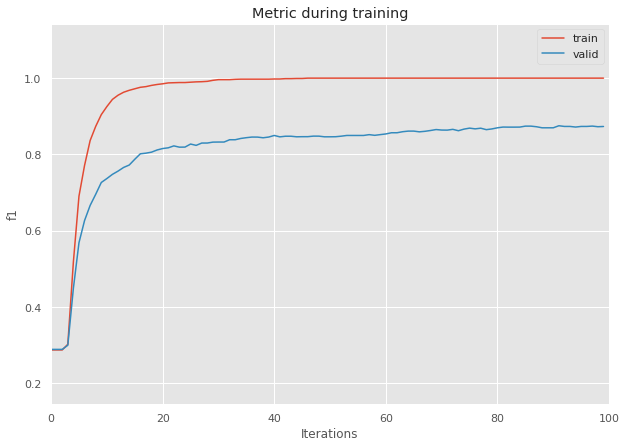

In [ ]:
lgb.plot_metric(evals_result, 'f1', figsize=(10, 7))
None

## CatBoost

In [ ]:
!pip install catboost

     |████████████████████████████████| 66.3MB 62kB/s 


In [ ]:
import catboost

In [ ]:
eval_dataset = catboost.Pool(X_tv, y_tv)
model = catboost.CatBoostClassifier(n_estimators=500, learning_rate=0.09, 
                                    depth=6, random_seed=SEED,
                                    loss_function='MultiClass', 
                                    eval_metric='TotalF1')
model.fit(X_tt, y_tt, eval_set=eval_dataset)
print(model.get_best_score())

0:	learn: 0.5948190	test: 0.5708423	best: 0.5708423 (0)	total: 1.38s	remaining: 11m 30s
1:	learn: 0.6055896	test: 0.5676616	best: 0.5708423 (0)	total: 2.73s	remaining: 11m 18s
2:	learn: 0.6010304	test: 0.5692232	best: 0.5708423 (0)	total: 4.09s	remaining: 11m 17s
3:	learn: 0.6181927	test: 0.5939301	best: 0.5939301 (3)	total: 5.46s	remaining: 11m 16s
4:	learn: 0.6215334	test: 0.6062933	best: 0.6062933 (4)	total: 6.81s	remaining: 11m 14s
5:	learn: 0.6436909	test: 0.6132168	best: 0.6132168 (5)	total: 8.14s	remaining: 11m 10s
6:	learn: 0.6509743	test: 0.6176065	best: 0.6176065 (6)	total: 9.52s	remaining: 11m 10s
7:	learn: 0.6594456	test: 0.6303373	best: 0.6303373 (7)	total: 10.9s	remaining: 11m 8s
8:	learn: 0.6661306	test: 0.6347558	best: 0.6347558 (8)	total: 12.2s	remaining: 11m 6s
9:	learn: 0.6773661	test: 0.6403286	best: 0.6403286 (9)	total: 13.6s	remaining: 11m 6s
10:	learn: 0.6804240	test: 0.6458366	best: 0.6458366 (10)	total: 15s	remaining: 11m 5s
11:	learn: 0.6880967	test: 0.6551965

In [ ]:
preds_train = model.predict(X_tt)
preds_valid = model.predict(X_tv)

score_train = f1_score(y_tt, preds_train, average='weighted')
score_valid = f1_score(y_tv, preds_valid, average='weighted')

print('Train score:', score_train)
print('Valid score:', score_valid)
print('Difference:', score_train - score_valid)

Train score: 0.9925803052260819
Valid score: 0.8891917747905727
Difference: 0.10338853043550922


## Stacking

In [ ]:
from sklearn.model_selection import StratifiedKFold
NFOLDS = 5

kf = StratifiedKFold(n_splits=NFOLDS, shuffle=True, random_state=SEED)

In [ ]:
class SklearnWrapper(object):
    def __init__(self, clf, seed=SEED, params=None):
        params['random_state'] = seed
        self.clf = clf(**params)

    def train(self, X_train, y_train, X_valid=None, y_valid=None):
        self.clf.fit(X_train, y_train)
    
    def predict(self, X):
        return self.clf.predict_proba(X)

class CatBoostWrapper(object):
    def __init__(self, clf, seed=SEED, params=None):
        params['random_state'] = seed
        self.clf = clf(**params)
    
    def train(self, X_train, y_train, X_valid, y_valid):
        eval_dataset = catboost.Pool(X_valid, y_valid)
        self.clf.fit(X_train, y_train, eval_set=eval_dataset, init_model=None)

    def predict(self, X):
        return self.clf.predict_proba(X)

def get_model_pred(clf, X_train, y_train, X_test):
    ntrain = X_train.shape[0]
    ntest = X_test.shape[0]
    labels = list(set(y_train))
    nlabels = len(labels)

    train = np.zeros((ntrain, nlabels))
    test = np.zeros((ntest, nlabels))
    test_folds = np.empty((NFOLDS, ntest, nlabels))

    for i, (train_index, valid_index) in enumerate(kf.split(X_train, y_train)):
        print(f'{i + 1} Fold\n')
        X_tr = X_train[train_index]
        y_tr = y_train[train_index]
        X_val = X_train[valid_index]
        y_val = y_train[valid_index]

        clf.train(X_tr, y_tr, X_val, y_val)

        train_preds = clf.predict(X_val)
        test_folds_preds = clf.predict(X_test)
                
        train[valid_index] = train_preds
        test_folds[i, :] = test_folds_preds
    
    test[:] = test_folds.mean(axis=0)
    return train.reshape(-1, nlabels), test.reshape(-1, nlabels)

In [ ]:
rf_params = {
    'n_estimators': 100, 
    'max_depth': 15,
    'max_features': 'sqrt'
}

cb_params = {
    'n_estimators': 100, 
    'learning_rate': 0.09,
    'depth': 6,
    'loss_function': 'MultiClass',
    'eval_metric': 'TotalF1',
    'verbose': 250
}

rf = SklearnWrapper(clf=RandomForestClassifier, seed=SEED, params=rf_params)
cb = CatBoostWrapper(clf=catboost.CatBoostClassifier, seed=SEED, 
                     params=cb_params)

rf_train, rf_test = get_model_pred(rf, X_train, y_train, X_test)
cb_train, cb_test = get_model_pred(cb, X_train, y_train, X_test)

print('Random Forest CV: {}'.format(f1_score(y_train, 
                                             np.argmax(rf_train, axis=1) + 1, 
                                             average='weighted')))
print('CatBoost CV: {}'.format(f1_score(y_train, 
                                        np.argmax(cb_train, axis=1) + 1, 
                                        average='weighted')))

X_train = np.concatenate((rf_train, cb_train), axis=1)
X_test = np.concatenate((rf_test, cb_test), axis=1)
print(X_train.shape, X_test.shape)

X_train = pd.DataFrame(X_train)
X_train.to_csv('/content/drive/MyDrive/Colab Notebooks/Hackatons/AgroCode/x_train.csv', index=False)
X_test = pd.DataFrame(X_test)
X_test.to_csv('/content/drive/MyDrive/Colab Notebooks/Hackatons/AgroCode/x_test.csv', index=False)

1 Fold

2 Fold

3 Fold

4 Fold

5 Fold

1 Fold

0:	learn: 0.5828869	test: 0.5591074	best: 0.5591074 (0)	total: 8.42s	remaining: 13m 53s
99:	learn: 0.8998683	test: 0.8334931	best: 0.8334931 (98)	total: 13m 46s	remaining: 0us

bestTest = 0.8334931446
bestIteration = 98

Shrink model to first 99 iterations.
2 Fold

0:	learn: 0.5759902	test: 0.5573607	best: 0.5573607 (0)	total: 8.76s	remaining: 14m 27s
99:	learn: 0.9024605	test: 0.8450700	best: 0.8450700 (97)	total: 14m 4s	remaining: 0us

bestTest = 0.8450700164
bestIteration = 97

Shrink model to first 98 iterations.
3 Fold

0:	learn: 0.5783461	test: 0.5767994	best: 0.5767994 (0)	total: 8.65s	remaining: 14m 16s
99:	learn: 0.9053958	test: 0.7967599	best: 0.7985690 (97)	total: 14m 7s	remaining: 0us

bestTest = 0.7985690214
bestIteration = 97

Shrink model to first 98 iterations.
4 Fold

0:	learn: 0.5813703	test: 0.5602731	best: 0.5602731 (0)	total: 8.5s	remaining: 14m 1s
99:	learn: 0.9098830	test: 0.8076892	best: 0.8095881 (98)	total: 14m 1

In [ ]:
X_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Hackatons/AgroCode/x_train.csv')
X_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Hackatons/AgroCode/x_test.csv')

In [ ]:
rf_test = X_test.iloc[:, :28]

In [ ]:
X_tt, X_tv, y_tt, y_tv = train_test_split(X_train, y_train, test_size=0.2, random_state=SEED)
log_reg = LogisticRegression()

params = {
    'C': [0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

grid = GridSearchCV(log_reg, params, scoring='f1_weighted', verbose=100).fit(X_train, y_train)

In [ ]:
grid.best_score_

0.8893507210464382

In [ ]:
model = grid.best_estimator_
model

LogisticRegression(C=100, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

## NN

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F

X = torch.FloatTensor(X_train.to_numpy())
y = torch.LongTensor(y_train.to_numpy())

D_in, H, D_out = 368, 100, 28

# Use the nn package to define our model and loss function.
model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
    torch.nn.Softmax()
)

loss_fn = nn.CrossEntropyLoss()
optim = torch.optim.Adam(model.parameters(), 1e-1)

losses = []
for t in range(100):
    # forward
    y_pred = model(X)

    # loss
    loss = loss_fn(y_pred, y)
    losses.append(loss.item())

    optim.zero_grad()
    loss.backward()
    optim.step()
    
plt.plot(losses)

IndexError: ignored

# Выгрузка

In [ ]:
# preds = model.predict(X_test).reshape(-1)  # CatBoost
# preds = model.predict(X_test).argmax(axis=1) + 1  # LightGBM
preds = np.argmax(rf_test, axis=1) + 1

pd.Series(preds).to_csv('preds.csv', index=False, header=['Culture'])